# Preprocessing Pipeline & Baseline Training

This is a **canonical preprocessing notebook**. It serves three purposes:

1. **Document** every preprocessing step with visualisations - the reference
   pipeline description for the methodology section and the Streamlit app.
2. **Train** FCN-Wang (the project baseline) on the best preprocessing configuration
   identified in `02_preprocessing_ablation.ipynb`.
3. **Export artifacts** consumed by later notebooks and the Streamlit app:
   `checkpoint.pt`, `metrics.json` (with 95 % CI), `preprocessing_config.json`,
   and example predictions for each superclass.

### Baseline model: FCN-Wang

| Property | Value |
|---|---|
| Architecture | FCN-Wang (Wang et al. 2017) + concat-pool head (Strodthoff et al. 2021, Appendix I) |
| Paper AUC | 0.925 (Strodthoff et al. Table II, super-diag) |
| Parameters | ~310k |
| Input | (B, 12, T) - any T due to adaptive pooling |
| Loss | BCEWithLogitsLoss + pos_weight |
| Optimiser | AdamW + 1-cycle LR |

All later notebooks (transformer training, final evaluation, explainability) load
this checkpoint as the **baseline** to beat.

## 1. Environment setup

In [1]:
import sys, os, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
import wfdb

from src.utils.config import CFG
from src.preprocessing.label_utils import load_all_labels, SUPERCLASSES

DATA_PATH    = CFG['data']['path']
RESULTS_PATH = CFG['paths']['results']
OUT_DIR      = Path(RESULTS_PATH) / '03_preprocessing_pipeline'
FIG_DIR      = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device       : {device}')
print(f'Project root : {PROJECT_ROOT}')

Device       : cuda
Project root : D:\GitHub\biosignal-xai


## 2. Load best preprocessing configuration from ablation

We read the `best_config.json` written by notebook 02. If the ablation has not
been run yet, we fall back to `bandpass_zscore_250` (bandpass filter + per-lead
z-score + 2.5-second overlapping windows), the config that is expected to perform
well based on ECG signal processing literature.

In [2]:
from src.preprocessing.dataset_ablation import ABLATION_CONFIGS, ABLATION_LABELS

ABLATION_RESULT_PATH = Path(RESULTS_PATH) / '02_preprocessing_ablation' / 'best_config.json'

if ABLATION_RESULT_PATH.exists():
    with open(ABLATION_RESULT_PATH) as f:
        best_cfg_meta = json.load(f)
    BEST_CONFIG_NAME = best_cfg_meta['config_name']
    print(f'Loaded from ablation : {BEST_CONFIG_NAME}')
    print(f'Label                : {best_cfg_meta["label"]}')
    print(f'Ablation AUC         : {best_cfg_meta["auc_ablation"]}')
else:
    BEST_CONFIG_NAME = 'bandpass_zscore_250'
    best_cfg_meta    = {'config_name': BEST_CONFIG_NAME,
                        'label': ABLATION_LABELS[BEST_CONFIG_NAME]}
    print(f'Ablation results not found, using default: {BEST_CONFIG_NAME}')

PREPROCESS_CFG = ABLATION_CONFIGS[BEST_CONFIG_NAME]
print(f'\nPreprocessing config:')
print(f'  filter_fn   : {PREPROCESS_CFG["filter_fn"].__name__ if PREPROCESS_CFG["filter_fn"] else "None"}')
print(f'  norm_fn     : {PREPROCESS_CFG["norm_fn"].__name__   if PREPROCESS_CFG["norm_fn"]   else "None"}')
print(f'  window_size : {PREPROCESS_CFG["window_size"]} samples ({PREPROCESS_CFG["window_size"]/100:.1f} s)')
print(f'  stride      : {PREPROCESS_CFG["stride"]} samples')

Loaded from ablation : bandpass_none_250
Label                : Bandpass only, 2.5 s
Ablation AUC         : 0.9272

Preprocessing config:
  filter_fn   : bandpass_filter
  norm_fn     : None
  window_size : 250 samples (2.5 s)
  stride      : 125 samples


## 3. Load labels and splits

In [3]:
Y = load_all_labels(
    db_path  = DATA_PATH + 'ptbxl_database.csv',
    scp_path = DATA_PATH + 'scp_statements.csv',
)

train_df = Y[Y['strat_fold'] <  9].copy()
val_df   = Y[Y['strat_fold'] == 9].copy()
test_df  = Y[Y['strat_fold'] == 10].copy()

import pandas as pd
label_matrix = np.stack(Y['label_vec'].values)
summary = pd.DataFrame({
    'Split':   ['Train', 'Val', 'Test'],
    'Records': [len(train_df), len(val_df), len(test_df)],
})
print(summary.to_string(index=False))

Records with valid labels: 21375
Class distribution:
  NORM: 9514 (44.5%)
  MI: 5469 (25.6%)
  STTC: 5108 (23.9%)
  CD: 4898 (22.9%)
  HYP: 2649 (12.4%)
Split  Records
Train    17073
  Val     2145
 Test     2157


## 4. Preprocessing pipeline: step-by-step visualisation

The pipeline consists of three sequential operations:

1. **Bandpass filter (0.5–40 Hz)**: removes baseline wander (< 0.5 Hz, caused by
   breathing and electrode movement) and high-frequency noise (> 40 Hz, muscle artefact
   and powerline interference). Uses a zero-phase Butterworth filter (`filtfilt`) so no
   time delay is introduced.
2. **Per-lead z-score normalisation**: subtracts the mean and divides by the standard
   deviation computed independently for each of the 12 leads. This makes all leads
   comparable in scale regardless of electrode placement or patient-specific voltage,
   without destroying waveform morphology.
3. **Sliding-window slicing**: the 10-second record (1000 samples @ 100 Hz) is split
   into overlapping windows of `window_size` samples with `stride` hop. A single record
   produces multiple training samples; all windows from the same record share the same label.

The cell below applies each step to a NORM example and a MI example side-by-side,
showing how the signal changes at each stage.

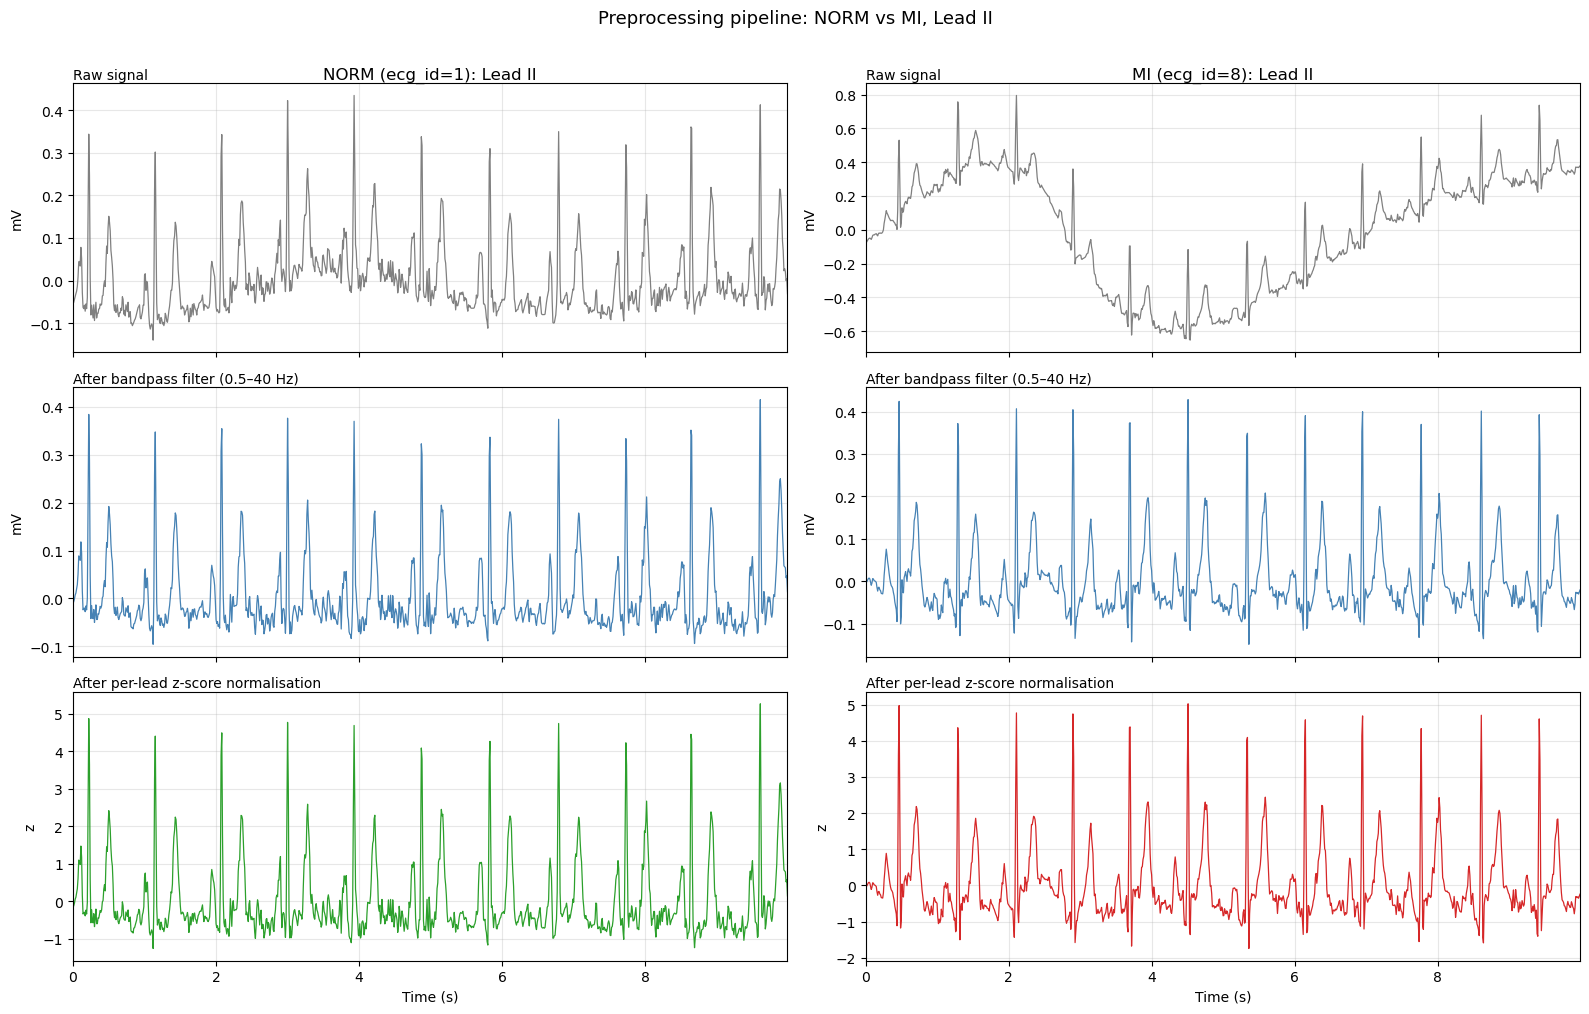

Saved → D:\GitHub\biosignal-xai\results\03_preprocessing_pipeline\figures\pipeline_steps_norm_mi.png


In [4]:
from src.preprocessing.preprocess import bandpass_filter, normalize_signal, create_windows

def pick_example(superclass, single_label=True):
    sc_idx   = SUPERCLASSES.index(superclass)
    lm       = np.stack(Y['label_vec'].values)
    mask     = lm[:, sc_idx] == 1
    if single_label:
        mask &= lm.sum(axis=1) == 1
    candidates = Y.index[mask]
    eid = candidates[0]
    row = Y.loc[eid]
    raw, meta = wfdb.rdsamp(DATA_PATH + row['filename_lr'])
    return eid, raw, meta, row

LEAD_NAME = 'II'
PALETTE   = {'NORM': '#2ca02c', 'MI': '#d62728'}

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex='col')
t = np.arange(1000) / 100

for col, sc in enumerate(['NORM', 'MI']):
    eid, raw, meta, row = pick_example(sc)
    lead_idx = meta['sig_name'].index(LEAD_NAME)
    color    = PALETTE[sc]

    filtered    = bandpass_filter(raw)
    normalised  = normalize_signal(filtered)

    steps = [
        (raw,        'Raw signal', 'mV',         'gray'),
        (filtered,   'After bandpass filter (0.5–40 Hz)', 'mV', 'steelblue'),
        (normalised, 'After per-lead z-score normalisation', 'z', color),
    ]

    for row_i, (sig, title, ylabel, c) in enumerate(steps):
        ax = axes[row_i][col]
        ax.plot(t, sig[:, lead_idx], linewidth=0.9, color=c)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.margins(x=0)
        if row_i == 0:
            ax.set_title(f'{sc} (ecg_id={eid}): Lead {LEAD_NAME}', fontsize=12)
        if row_i == 2:
            ax.set_xlabel('Time (s)')
        ax.set_title(title, fontsize=10, loc='left', pad=3)

fig.suptitle('Preprocessing pipeline: NORM vs MI, Lead II', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'pipeline_steps_norm_mi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR / "pipeline_steps_norm_mi.png"}')

### 4.1 Spectral analysis: what the filter removes

We use `src/preprocessing/signal_analysis.py` to compute Welch power spectral
density before and after filtering. The plot shows the three spectral regions:
baseline wander (< 0.5 Hz), the diagnostic ECG band (0.5–40 Hz), and high-frequency
noise (> 40 Hz). The bandpass filter should attenuate the outer bands without
touching the diagnostic band.

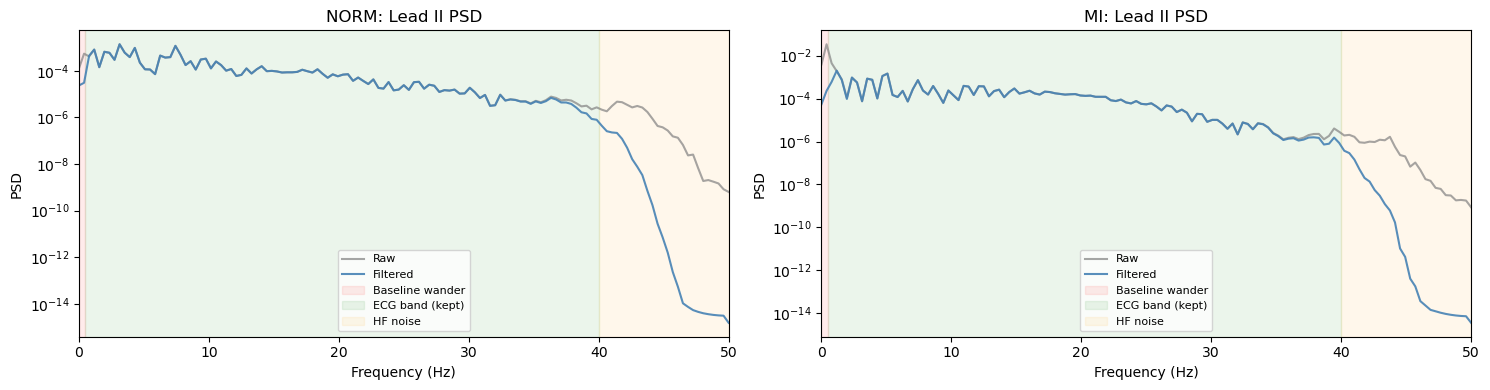

In [5]:
from src.preprocessing.signal_analysis import welch_psd, signal_quality_summary

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, sc in zip(axes, ['NORM', 'MI']):
    _, raw, meta, _ = pick_example(sc)
    filtered = bandpass_filter(raw)
    lead_idx = meta['sig_name'].index(LEAD_NAME)

    freqs_r, psd_r = welch_psd(raw[:, lead_idx:lead_idx+1])
    freqs_f, psd_f = welch_psd(filtered[:, lead_idx:lead_idx+1])

    ax.semilogy(freqs_r, psd_r[:, 0], color='gray',      alpha=0.7, label='Raw')
    ax.semilogy(freqs_f, psd_f[:, 0], color='steelblue', alpha=0.9, label='Filtered')

    ax.axvspan(0,    0.5,  color='red',    alpha=0.08, label='Baseline wander')
    ax.axvspan(0.5,  40,   color='green',  alpha=0.08, label='ECG band (kept)')
    ax.axvspan(40,   50,   color='orange', alpha=0.08, label='HF noise')

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.set_title(f'{sc}: Lead {LEAD_NAME} PSD')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 50)

plt.tight_layout()
fig.savefig(FIG_DIR / 'spectral_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Windowing: sliding windows from one record

A single 10-second PTB-XL record (1000 samples) is sliced into overlapping
windows. With window_size=250 (2.5 s) and stride=125 (50 % overlap), one record
yields 7 training samples. All windows share the record-level label.

Record length : 1000 samples (10 s @ 100 Hz)
Window size   : 250 samples (2.5 s)
Stride        : 125 samples (1.2 s)
Windows       : 7


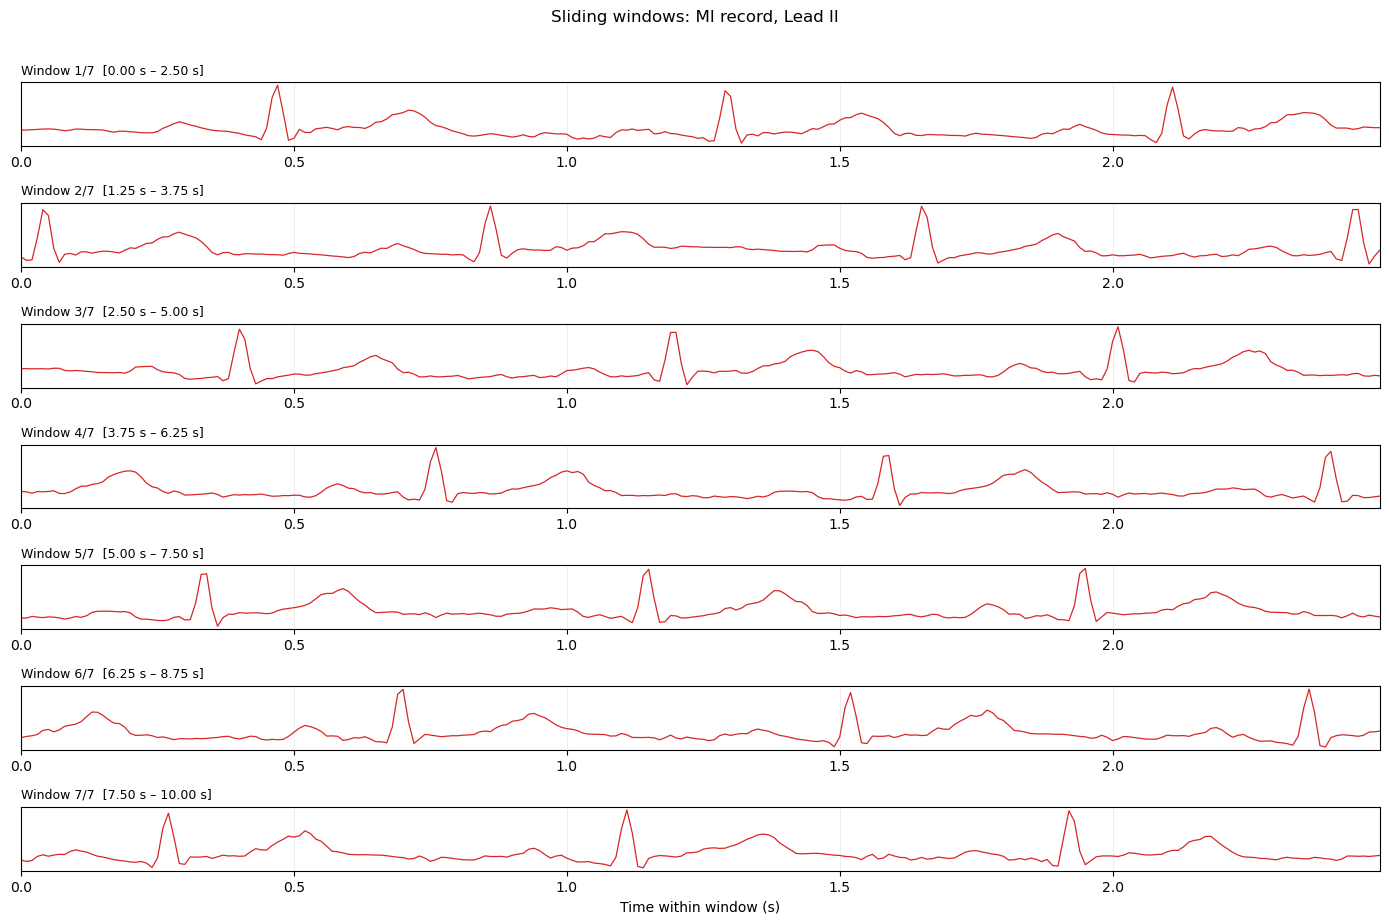

In [6]:
_, raw_eg, meta_eg, row_eg = pick_example('MI')
lead_idx_eg = meta_eg['sig_name'].index(LEAD_NAME)

filt_eg = bandpass_filter(raw_eg)
norm_eg = normalize_signal(filt_eg)
windows = create_windows(norm_eg,
                          window_size=PREPROCESS_CFG['window_size'],
                          stride=PREPROCESS_CFG['stride'])

print(f'Record length : {len(norm_eg)} samples (10 s @ 100 Hz)')
print(f'Window size   : {PREPROCESS_CFG["window_size"]} samples ({PREPROCESS_CFG["window_size"]/100:.1f} s)')
print(f'Stride        : {PREPROCESS_CFG["stride"]} samples ({PREPROCESS_CFG["stride"]/100:.1f} s)')
print(f'Windows       : {len(windows)}')

fig, axes = plt.subplots(len(windows), 1, figsize=(14, len(windows) * 1.3), sharex=False)
if len(windows) == 1:
    axes = [axes]
for i, (w, ax) in enumerate(zip(windows, axes)):
    t_w = np.arange(len(w)) / 100
    ax.plot(t_w, w[:, lead_idx_eg], linewidth=0.9, color='#d62728')
    start_s = i * PREPROCESS_CFG['stride'] / 100
    ax.set_title(f'Window {i+1}/{len(windows)}  [{start_s:.2f} s – {start_s + PREPROCESS_CFG["window_size"]/100:.2f} s]',
                 fontsize=9, loc='left')
    ax.set_yticks([])
    ax.grid(True, alpha=0.2)
    ax.margins(x=0)
axes[-1].set_xlabel('Time within window (s)')
fig.suptitle(f'Sliding windows: MI record, Lead {LEAD_NAME}', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sliding_windows.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Normalisation comparison: all four strategies

For completeness we show what each normalisation strategy produces on the same
lead-II signal. Robust z-score (median/MAD) is more resistant to spike artefacts
than standard z-score. Min-max preserves relative amplitudes across leads at the
cost of sensitivity to outlier peaks.

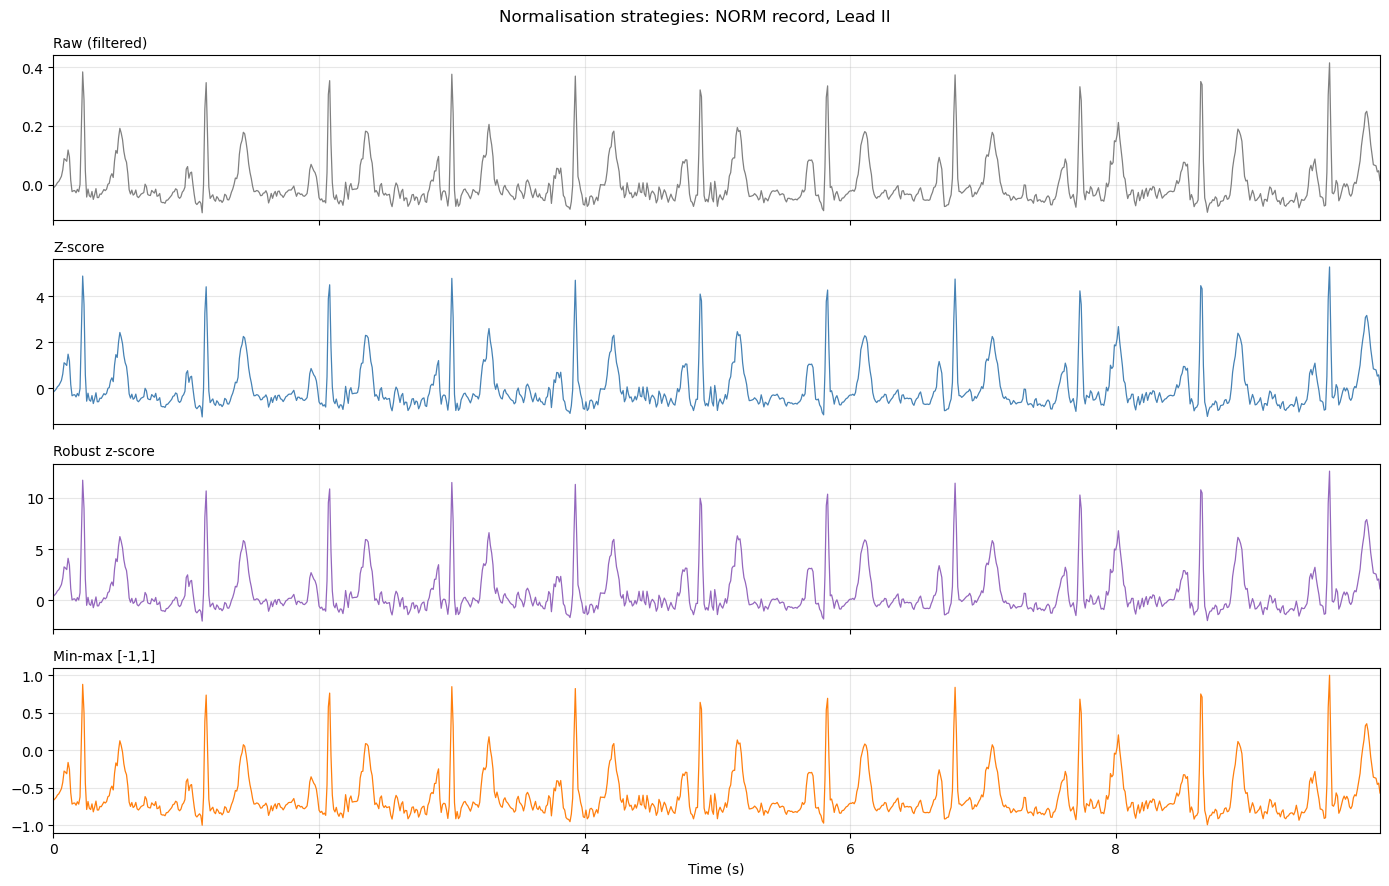

In [7]:
from src.preprocessing.preprocess import normalize_minmax, normalize_robust

_, raw_n, meta_n, _ = pick_example('NORM')
lead_n = meta_n['sig_name'].index(LEAD_NAME)
filt_n = bandpass_filter(raw_n)

norm_variants = [
    ('Raw (filtered)', filt_n,                     'gray'),
    ('Z-score',        normalize_signal(filt_n),   'steelblue'),
    ('Robust z-score', normalize_robust(filt_n),   '#9467bd'),
    ('Min-max [-1,1]', normalize_minmax(filt_n),   '#ff7f0e'),
]

fig, axes = plt.subplots(len(norm_variants), 1, figsize=(14, 9), sharex=True)
t_full = np.arange(1000) / 100

for ax, (label, sig, color) in zip(axes, norm_variants):
    ax.plot(t_full, sig[:, lead_n], linewidth=0.9, color=color)
    ax.set_title(label, fontsize=10, loc='left')
    ax.grid(True, alpha=0.3)
    ax.margins(x=0)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Normalisation strategies: NORM record, Lead {LEAD_NAME}', fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / 'norm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Build datasets and DataLoaders

We use `ECGDatasetAblation` with the best preprocessing config. This is the exact
same class used in the ablation notebook, so the training setup is fully reproducible.

In [8]:
from src.preprocessing.dataset_ablation import ECGDatasetAblation
from torch.utils.data import DataLoader

BATCH_SIZE   = 256   # FCN-Wang is tiny; 256 gives ~3× GPU throughput vs 64
NUM_WORKERS  = CFG['training']['num_workers']

train_ds = ECGDatasetAblation(train_df, DATA_PATH, **PREPROCESS_CFG)
val_ds   = ECGDatasetAblation(val_df,   DATA_PATH, **PREPROCESS_CFG)
test_ds  = ECGDatasetAblation(test_df,  DATA_PATH, **PREPROCESS_CFG)

print(f'Train windows : {len(train_ds):,}')
print(f'Val windows   : {len(val_ds):,}')
print(f'Test windows  : {len(test_ds):,}')

# Verify batch shape
loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=NUM_WORKERS)
x_b, y_b = next(iter(loader))
print(f'\nBatch shapes:')
print(f'  x : {tuple(x_b.shape)}  (batch, leads, time)')
print(f'  y : {tuple(y_b.shape)}  (batch, classes)')

Train windows : 119,511
Val windows   : 15,015
Test windows  : 15,099

Batch shapes:
  x : (4, 12, 250)  (batch, leads, time)
  y : (4, 5)  (batch, classes)


## 6. Model: FCN-Wang

This is the project baseline. We train it from scratch (random initialisation)
using the full training set and the best preprocessing config. After training this
checkpoint becomes the **baseline** for all subsequent transformer experiments.

In [9]:
from src.models.fcn_wang import fcn_wang

model = fcn_wang()
p = model.count_parameters()
print(f'Parameters : {p["total"]:,} total ({p["trainable"]:,} trainable)')

# Confirm forward pass
with torch.no_grad():
    dummy = torch.zeros(2, 12, PREPROCESS_CFG['window_size'])
    out   = model(dummy)
print(f'Output shape : {tuple(out.shape)}  ✓')

FCN-Wang | Params: 309,765 total, 309,765 trainable (100.0%)
Parameters : 309,765 total (309,765 trainable)
Output shape : (2, 5)  ✓


## 7. Training: full FCN-Wang baseline

Training uses `train_baseline()` from `src/training/train_baseline.py` which implements
the Strodthoff et al. (2021) Appendix I protocol:
- **AdamW** optimiser (weight decay 0.01)
- **1-cycle LR schedule** — linear warm-up to 1e-3, then cosine decay
- **BCEWithLogitsLoss** with positive class weights `[1.0, 1.74, 1.82, 1.94, 3.59]`
  to compensate for PTB-XL class imbalance (HYP is ~3× rarer than NORM)
- **Early stopping** on validation macro-AUC (patience = 8 epochs)
- **Gradient clipping** at norm 1.0

Expected training time: ~5 min for 50 epochs on RTX 4060 (FCN-Wang is ~40× smaller
than XResNet1D-101 so epochs are much faster).

In [11]:
from src.training.train_baseline import train_baseline

best_auc, history, profiling = train_baseline(
    model           = model,
    train_ds        = train_ds,
    val_ds          = val_ds,
    experiment_name = 'fcn_wang_baseline',
    epochs          = CFG['training']['epochs'],
    lr_peak         = 1e-3,
    batch_size      = BATCH_SIZE,
    patience        = 2,
    num_workers     = NUM_WORKERS,
)

print(f'\nBest validation AUC : {best_auc:.4f}')
print(f'Paper target         : 0.9250  (FCN-Wang, Strodthoff et al. Table II)')


 Experiment : fcn_wang_baseline
 Device     : cuda  |  AMP: True  |  compile: False
 Params     : 309,765 total | 309,765 trainable (100.0%)
 Epochs     : 15  |  LR peak: 1e-03  |  BS: 256
Epoch 001/15  lr=1.52e-04  train=0.7023  val=0.5059  AUC=0.8989  Fmax=0.7009
  ✓ Best AUC 0.8989 — saved → D:\GitHub\biosignal-xai\results/fcn_wang_baseline\checkpoint.pt
Epoch 002/15  lr=4.37e-04  train=0.5175  val=0.4290  AUC=0.9149  Fmax=0.7255
  ✓ Best AUC 0.9149 — saved → D:\GitHub\biosignal-xai\results/fcn_wang_baseline\checkpoint.pt
Epoch 003/15  lr=7.60e-04  train=0.4165  val=0.4099  AUC=0.9212  Fmax=0.7322
  ✓ Best AUC 0.9212 — saved → D:\GitHub\biosignal-xai\results/fcn_wang_baseline\checkpoint.pt
Epoch 004/15  lr=9.71e-04  train=0.3807  val=0.3960  AUC=0.9279  Fmax=0.7477
  ✓ Best AUC 0.9279 — saved → D:\GitHub\biosignal-xai\results/fcn_wang_baseline\checkpoint.pt
Epoch 005/15  lr=9.94e-04  train=0.3586  val=0.4041  AUC=0.9269  Fmax=0.7390
Epoch 006/15  lr=9.50e-04  train=0.3418  val=0.40

### 7.1 Learning curves

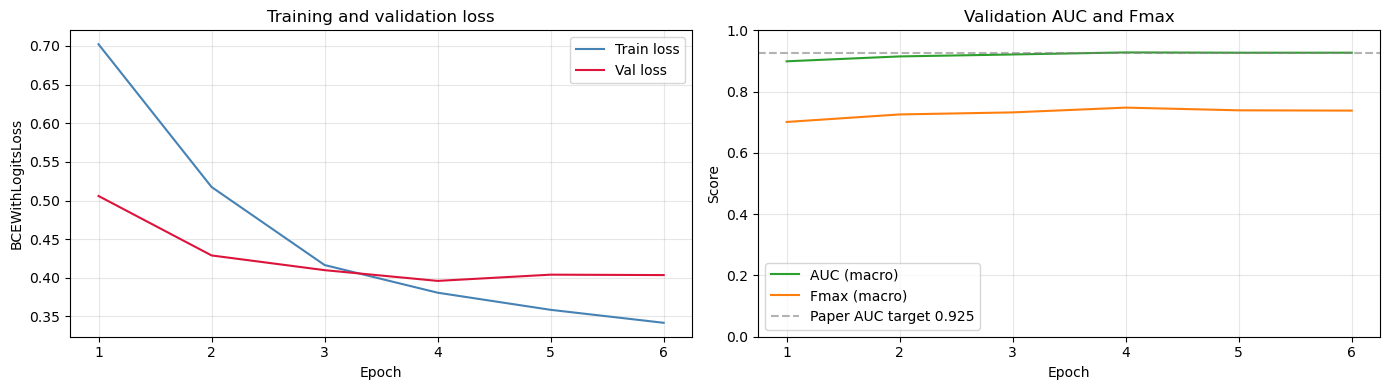

In [12]:
epochs_x    = [h['epoch'] for h in history]
train_loss  = [h['train_loss'] for h in history]
val_loss    = [h['val_loss'] for h in history]
aucs        = [h['auc_macro'] for h in history]
fmaxs       = [h['fmax'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(epochs_x, train_loss, label='Train loss', color='steelblue')
ax1.plot(epochs_x, val_loss,   label='Val loss',   color='crimson')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.set_title('Training and validation loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_x, aucs,  label='AUC (macro)',  color='#2ca02c')
ax2.plot(epochs_x, fmaxs, label='Fmax (macro)', color='#ff7f0e')
ax2.axhline(0.925, linestyle='--', color='gray', alpha=0.6, label='Paper AUC target 0.925')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_title('Validation AUC and Fmax')
ax2.set_ylim(0, 1.0)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final evaluation on the test set

We load the best checkpoint (saved during training) and evaluate on the held-out
test fold (fold 10). This is the number we report in the final comparison table.

Metrics follow the paper:
- **Macro AUC**: primary metric, threshold-free, term-centric
- **Fmax**: secondary metric, sample-centric F1 maximised over thresholds
- **95 % CI**: 1 000-iteration bootstrap (matches paper Appendix I)

In [13]:
from src.models.fcn_wang import FCNWang
from src.evaluation.metrics import full_eval, print_eval, compute_probs

ckpt_path = Path(RESULTS_PATH) / 'fcn_wang_baseline' / 'checkpoint.pt'
model_test = FCNWang.load(str(ckpt_path)).to(device)
model_test.eval()

# Collect test set logits
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
all_logits, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        logits = model_test(x.to(device))
        all_logits.append(logits.cpu())
        all_labels.append(y)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

print('Running full evaluation (with 1000-iter bootstrap CI, ~30 s) ...')
test_metrics = full_eval(all_logits, all_labels, run_bootstrap=True, n_bootstrap=1000)

print('\nFCN-Wang: Test Set Results')
print_eval(test_metrics)
print(f'\nPaper benchmark (Strodthoff et al.): AUC 0.925, Fmax 0.643')

FCN-Wang | Params: 309,765 total, 309,765 trainable (100.0%)


D:\GitHub\biosignal-xai\src\models\fcn_wang.py:202: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location='cpu'))


Running full evaluation (with 1000-iter bootstrap CI, ~30 s) ...

FCN-Wang: Test Set Results
  AUC  (macro): 0.9225  95% CI: 0.922 [0.920, 0.925]
  Fmax (macro): 0.7458  @ τ=0.48  95% CI: 0.746 [0.740, 0.752]
  AUPRC(macro): 0.8163
  Per-class AUC:
    NORM : 0.944  ███████████████████████
    MI   : 0.928  ███████████████████████
    STTC : 0.933  ███████████████████████
    CD   : 0.907  ██████████████████████
    HYP  : 0.900  ██████████████████████

Paper benchmark (Strodthoff et al.): AUC 0.925, Fmax 0.643


### 8.1 Per-class AUC breakdown

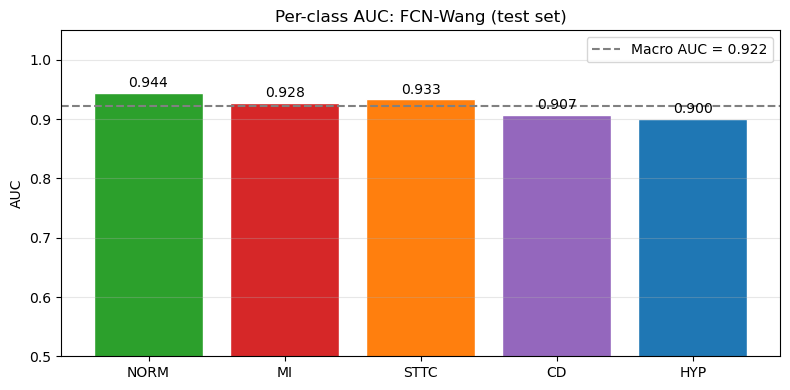

In [14]:
PALETTE = ['#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#1f77b4']

per_class_aucs = [test_metrics['per_class_auc'][sc] for sc in SUPERCLASSES]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(SUPERCLASSES, per_class_aucs, color=PALETTE, edgecolor='white')
for bar, v in zip(bars, per_class_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.axhline(test_metrics['auc_macro'], linestyle='--', color='gray',
           label=f'Macro AUC = {test_metrics["auc_macro"]:.3f}')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('AUC')
ax.set_title('Per-class AUC: FCN-Wang (test set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'per_class_auc.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Inference latency

In [15]:
from src.evaluation.latency import benchmark_latency

print('Benchmarking inference latency...')
latency_report = benchmark_latency(
    model_test,
    input_shape = (12, PREPROCESS_CFG['window_size']),
    batch_sizes = [1, 4, 16, 32, 64],
)
print('\n' + latency_report['summary_table'])

Benchmarking inference latency...
  bs=  1 | median    1.0 ms | 1.03 ms/sample | 972 samples/s
  bs=  4 | median    1.6 ms | 0.41 ms/sample | 2454 samples/s
  bs= 16 | median    1.8 ms | 0.11 ms/sample | 9136 samples/s
  bs= 32 | median    1.3 ms | 0.04 ms/sample | 24519 samples/s
  bs= 64 | median    1.5 ms | 0.02 ms/sample | 43744 samples/s

  bs   median ms   ms/sample   samples/s
----------------------------------------
   1         1.0        1.03         972
   4         1.6        0.41        2454
  16         1.8        0.11        9136
  32         1.3        0.04       24519
  64         1.5        0.02       43744


### 8.3 Example predictions: one record per superclass

We load the `example_records.json` saved by notebook 01 and run the model on each
representative record. This produces the sample predictions displayed in the
Streamlit app's demo page.

In [16]:
from src.preprocessing.dataset_ablation import aggregate_window_predictions

examples_path = Path(RESULTS_PATH) / '01_data_exploration' / 'example_records.json'

if examples_path.exists():
    with open(examples_path) as f:
        examples = json.load(f)

    example_preds = {}
    model_test.eval()

    for sc, meta_ex in examples.items():
        raw, _ = wfdb.rdsamp(DATA_PATH + meta_ex['filename_lr'])

        # Apply best preprocessing
        sig = raw.copy()
        if PREPROCESS_CFG['filter_fn'] is not None:
            sig = PREPROCESS_CFG['filter_fn'](sig)
        if PREPROCESS_CFG['norm_fn'] is not None:
            sig = PREPROCESS_CFG['norm_fn'](sig)
        sig = sig.astype(np.float32)

        # Create windows manually
        ws, st = PREPROCESS_CFG['window_size'], PREPROCESS_CFG['stride']
        windows_ex = [sig[i:i+ws] for i in range(0, len(sig)-ws+1, st)]

        with torch.no_grad():
            batch_t = torch.tensor(np.stack([w.T for w in windows_ex]))
            logits  = model_test(batch_t.to(device)).cpu()

        probs = torch.sigmoid(logits).mean(dim=0)   # mean-pool windows

        pred_classes = [SUPERCLASSES[i] for i, v in enumerate(probs) if v > 0.5]
        example_preds[sc] = {
            'ecg_id':       meta_ex['ecg_id'],
            'true_class':   sc,
            'probs':        {SUPERCLASSES[i]: round(float(probs[i]), 4) for i in range(5)},
            'pred_classes': pred_classes,
            'correct':      sc in pred_classes,
        }

        flag = '✓' if sc in pred_classes else '✗'
        prob_str = '  '.join(f'{SUPERCLASSES[i]}: {probs[i]:.3f}' for i in range(5))
        print(f'{flag} {sc:4s}  |  {prob_str}')
else:
    print('example_records.json not found, run notebook 01 first.')
    example_preds = {}

✓ NORM  |  NORM: 0.978  MI: 0.015  STTC: 0.025  CD: 0.020  HYP: 0.004
✓ MI    |  NORM: 0.004  MI: 0.996  STTC: 0.088  CD: 0.585  HYP: 0.023
✗ STTC  |  NORM: 0.922  MI: 0.019  STTC: 0.095  CD: 0.074  HYP: 0.015
✗ CD    |  NORM: 0.759  MI: 0.208  STTC: 0.024  CD: 0.056  HYP: 0.062
✗ HYP   |  NORM: 0.858  MI: 0.013  STTC: 0.028  CD: 0.130  HYP: 0.431


## 9. Persist all artifacts

Everything saved here is consumed by downstream notebooks and the Streamlit app:

- `preprocessing_config.json`: the canonical config for signal processing
- `metrics.json`: test AUC, Fmax, AUPRC, 95 % CI, per-class breakdown, latency
- `training_history.json`: epoch-level training curves
- `example_predictions.json`: sample model outputs for the demo page
- `figures/`: publication-quality plots

In [17]:
# 1. Preprocessing config
preproc_payload = {
    'config_name':   BEST_CONFIG_NAME,
    'label':         ABLATION_LABELS[BEST_CONFIG_NAME],
    'filter_fn':     PREPROCESS_CFG['filter_fn'].__name__ if PREPROCESS_CFG['filter_fn'] else None,
    'norm_fn':       PREPROCESS_CFG['norm_fn'].__name__   if PREPROCESS_CFG['norm_fn']   else None,
    'window_size':   PREPROCESS_CFG['window_size'],
    'stride':        PREPROCESS_CFG['stride'],
    'sampling_rate': CFG['data']['sampling_rate'],
    'window_sec':    PREPROCESS_CFG['window_size'] / CFG['data']['sampling_rate'],
    'n_leads':       12,
    'filter_cutoffs_hz': [0.5, 40.0],
    'filter_order':  4,
}
(OUT_DIR / 'preprocessing_config.json').write_text(json.dumps(preproc_payload, indent=2))

# 2. Test metrics
metrics_payload = {
    'model':         'FCN-Wang',
    'preprocessing': BEST_CONFIG_NAME,
    'split':         'test (fold 10)',
    'paper_target':  {'auc_macro': 0.925, 'fmax': 0.643},
    **{k: (round(v, 5) if isinstance(v, float) else v)
       for k, v in test_metrics.items()},
    'latency': latency_report['results'],
    'model_params': profiling['total_params'],
}
(OUT_DIR / 'metrics.json').write_text(json.dumps(metrics_payload, indent=2))

# 3. Training history
(OUT_DIR / 'training_history.json').write_text(json.dumps(
    {'experiment': 'fcn_wang_baseline', 'history': history}, indent=2
))

# 4. Example predictions
if example_preds:
    (OUT_DIR / 'example_predictions.json').write_text(
        json.dumps(example_preds, indent=2)
    )

print('Artifacts written:')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(Path(RESULTS_PATH))}  ({p.stat().st_size / 1024:.1f} KB)')

Artifacts written:
  03_preprocessing_pipeline\example_predictions.json  (1.3 KB)
  03_preprocessing_pipeline\figures\norm_comparison.png  (351.7 KB)
  03_preprocessing_pipeline\figures\per_class_auc.png  (38.5 KB)
  03_preprocessing_pipeline\figures\pipeline_steps_norm_mi.png  (498.2 KB)
  03_preprocessing_pipeline\figures\sliding_windows.png  (258.4 KB)
  03_preprocessing_pipeline\figures\spectral_analysis.png  (102.4 KB)
  03_preprocessing_pipeline\figures\training_curves.png  (87.9 KB)
  03_preprocessing_pipeline\metrics.json  (2.2 KB)
  03_preprocessing_pipeline\preprocessing_config.json  (0.3 KB)
  03_preprocessing_pipeline\training_history.json  (2.2 KB)


## Appendix: additional visualisations for the preprocessing steps

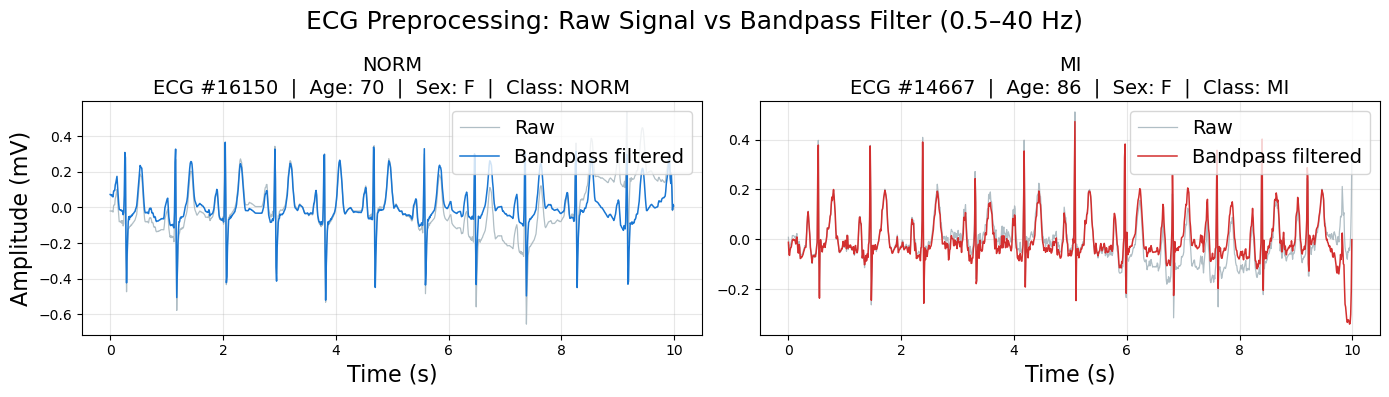

Saved preprocessing_raw_vs_bandpass.png


In [2]:
import json, wfdb, numpy as np
import matplotlib.pyplot as plt
from src.utils.config import CFG
from src.preprocessing.preprocess import bandpass_filter

DATA_PATH    = CFG['data']['path']
RESULTS_DIR  = '../results/03_preprocessing_pipeline/figures'

# Load curated records
curated = json.load(open('../app/data/curated_200.json'))

# Pick one NORM and one MI record
norm_rec = next(r for r in curated if r['superclass'] == ['NORM'])
mi_rec   = next(r for r in curated if r['superclass'] == ['MI'])

def load(rec):
    sig, _ = wfdb.rdsamp(DATA_PATH + rec['filename_lr'])
    return sig.astype(np.float32)   # (1000, 12)

def meta(rec):
    sex = 'F' if str(rec.get('sex')) in {'1', 'F'} else 'M'
    return (f"ECG #{rec['ecg_id']}  |  Age: {int(rec['age'])}  |  "
            f"Sex: {sex}  |  Class: {', '.join(rec['superclass'])}")


norm_raw = load(norm_rec)
mi_raw   = load(mi_rec)

norm_bp  = bandpass_filter(norm_raw)
mi_bp    = bandpass_filter(mi_raw)

t = np.arange(1000) / 100.0   # time axis in seconds

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
fig.suptitle('ECG Preprocessing: Raw Signal vs Bandpass Filter (0.5–40 Hz)',
             fontsize=18)

# NORM — overlaid
axes[0].plot(t, norm_raw[:, 1], color='#b0bec5', lw=0.9, label='Raw', zorder=1)
axes[0].plot(t, norm_bp[:, 1],  color='#1976d2', lw=1.1, label='Bandpass filtered', zorder=2)
axes[0].set_title(f'NORM\n{meta(norm_rec)}', fontsize=14)
axes[0].set_ylabel('Amplitude (mV)', fontsize=16)
axes[0].set_xlabel('Time (s)', fontsize=16)
axes[0].legend(fontsize=14, loc='upper right')
axes[0].grid(alpha=0.3)

# MI — overlaid
axes[1].plot(t, mi_raw[:, 1], color='#b0bec5', lw=0.9, label='Raw', zorder=1)
axes[1].plot(t, mi_bp[:, 1],  color='#d32f2f', lw=1.1, label='Bandpass filtered', zorder=2)
axes[1].set_title(f'MI\n{meta(mi_rec)}', fontsize=14)
axes[1].set_xlabel('Time (s)', fontsize=16)
axes[1].legend(fontsize=14, loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/preprocessing_raw_vs_bandpass.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved preprocessing_raw_vs_bandpass.png')

# fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True)
# fig.suptitle('ECG Preprocessing: Raw Signal vs Bandpass Filter (0.5–40 Hz)',
#              fontsize=14, fontweight='bold', y=1.01)
# 
# # NORM — raw
# axes[0, 0].plot(t, norm_raw[:, 1], color='#607d8b', lw=0.8)
# axes[0, 0].set_title(f'Raw signal\n{meta(norm_rec)}', fontsize=10)
# axes[0, 0].set_ylabel('Amplitude (mV)', fontsize=10)
# axes[0, 0].grid(alpha=0.3)
# 
# # NORM — bandpass
# axes[1, 0].plot(t, norm_bp[:, 1], color='#1976d2', lw=0.9)
# axes[1, 0].set_title('After bandpass filter (0.5–40 Hz)', fontsize=10)
# axes[1, 0].set_ylabel('Amplitude (mV)', fontsize=10)
# axes[1, 0].set_xlabel('Time (s)', fontsize=10)
# axes[1, 0].grid(alpha=0.3)
# 
# # MI — raw
# axes[0, 1].plot(t, mi_raw[:, 1], color='#607d8b', lw=0.8)
# axes[0, 1].set_title(f'Raw signal\n{meta(mi_rec)}', fontsize=10)
# axes[0, 1].grid(alpha=0.3)
# 
# # MI — bandpass
# axes[1, 1].plot(t, mi_bp[:, 1], color='#d32f2f', lw=0.9)
# axes[1, 1].set_title('After bandpass filter (0.5–40 Hz)', fontsize=10)
# axes[1, 1].set_xlabel('Time (s)', fontsize=10)
# axes[1, 1].grid(alpha=0.3)

# # Column labels
# axes[0, 0].text(0.01, 0.97, 'NORM', transform=axes[0, 0].transAxes,
#                 fontsize=12, fontweight='bold', color='#1976d2', va='top')
# axes[0, 1].text(0.01, 0.97, 'MI', transform=axes[0, 1].transAxes,
#                 fontsize=12, fontweight='bold', color='#d32f2f', va='top')
# 
# plt.tight_layout()
# plt.savefig(f'{RESULTS_DIR}/preprocessing_raw_vs_bandpass.png',
#             dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved preprocessing_raw_vs_bandpass.png')